# Общий внутренний механизм подавления candidate reserve

## Где находится исследование перед этим экспериментом

### 1. Что именно считается успешной атакой

На чистом изображении фиксируется конкретный человек: самый уверенный clean detection класса `person`. После наложения патча мы ищем **того же человека** по `IoU >= 0.5`; атака успешна, если у него не остаётся detection с `confidence >= 0.25`. Смена глобально самого уверенного человека не считается успехом. Старое image-level определение совпадало с новым только в 73% случаев и создавало ложный акцент на winner promotion.

### 2. Какие первоначальные объяснения не подтвердились

Гипотезы «патч не расползся» и «патч расползся не туда» плохо объясняют детектор. Успешные и неуспешные атаки не отличаются шириной поддержки causal contributions: доля абсолютного вклада в top 0.1% почти постоянна (`0.799–0.810`). Отличается прежде всего амплитуда signed target-relevant effect. У hidden target exact logit suppression примерно вдвое сильнее, а first-order clean gradient объясняет лишь небольшую часть изменения. Нелинейный residual особенно велик в `hidden_no_iou_match`.

### 3. Что показало causal tracing

Winner promotion не объясняет внутренний путь атаки: две visible-группы — target остаётся winner и выигрывает другой person — имеют практически одинаковые exact delta и causal magnitude. Потеря IoU выглядит более сильным и более нелинейным режимом подавления, но branch factorial показал, что endpoint-механизмы всё же различаются: для `hidden_low_conf_match` достаточно главным образом class branch, а для `hidden_no_iou_match` существенны и class, и box branches. NMS в большинстве случаев не является главным источником hiding.

### 4. Почему анализ одного tracked cell оказался недостаточным

После подавления исходного clean winner объект часто сохраняется за счёт соседнего кандидата. Среди 3,935 trace-visible примеров исходный tracked candidate остаётся winner только в 617 случаях (15.7%); другой кандидат из clean target set выигрывает в 2,806 случаях (71.3%); принципиально новый кандидат — лишь в 512 случаях (13.0%). Поэтому `clean_set_max_patch` предсказывает hiding лучше tracked score: ROC AUC `0.932` против `0.868`.

### 5. Что доказал причинный эксперимент с candidate reserve

У одного человека обычно есть около 9–10 pre-NMS clean candidates. При low-confidence hiding восстановление clean-logit одного правильно выбранного кандидата возвращает target в 90% случаев, top-2 — в 93%, а полный набор — в 99%. Обратный transplant почти ничего не делает до top-8, затем даёт 6% hiding на top-9 и скачок до 86% на top-10. Score/level-matched случайные кандидаты дают 0%. Для `hidden_no_iou_match` полный score-only эффект слабее: около 61% repair и 57% transplant, что согласуется с отдельным геометрическим вкладом.

### 6. Граница научной новизны

Само утверждение «для появления достаточно одного кандидата, а для скрытия нужно подавить все» следует из max/NMS-агрегации и не является центральной новизной. Нетривиальный открытый вопрос находится уровнем выше: **как локальный патч согласованно подавляет распределённый набор кандидатов одного человека?**

## Новая проверяемая гипотеза

> Успешный патч не создаёт десять независимых повреждений. На входе Detect head существует общий низкоразмерный компонент изменения признаков, разделяемый clean target candidates и причинно отвечающий за согласованное истощение candidate reserve.

Для каждого кандидата извлекается patch-induced delta из его `5×5` receptive window на входе соответствующего Detect level. Строки объединяются в матрицу «кандидаты × локальные признаки» и раскладываются SVD. Затем компоненты причинно проверяются в обе стороны:

- **repair:** общий rank-k компонент удаляется из patched features;
- **transplant:** тот же компонент переносится в clean features;
- **translated-layout control:** тот же candidate layout измеряется в другой области feature map;
- **top-absolute и random energy-matched controls:** восстанавливается столько же squared activation energy, но без SVD-структуры;
- **full target-window oracle:** весь patch-induced delta в объединении target windows возвращается к clean или переносится в clean.

Подтверждением гипотезы будет одновременно: повышенная rank-1 концентрация именно в target layout; сильный rank-1 repair; заметный rank-1 transplant; преимущество rank-1 над energy-matched controls. Одна лишь высокая rank-1 energy без причинной специфичности недостаточна.

Ограничение: SVD строится отдельно для каждого изображения и пока является oracle decomposition, а не универсальным направлением между изображениями.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

ROOT = Path.cwd()
if ROOT.name == 'CandidateRoutingAndAttackPath':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from CandidateRoutingAndAttackPath.shared_candidate_mechanism import (
    SharedCandidateMechanismConfig, run_shared_candidate_mechanism,
)

sns.set_theme(style='whitegrid', context='notebook')
OUTPUT_ROOT = ROOT / 'CandidateRoutingAndAttackPath' / 'followup_outputs'
RUN_EXPERIMENT = False  # True для нового тяжёлого запуска
DEVICE = 'mps'

if RUN_EXPERIMENT:
    RUN_DIR = run_shared_candidate_mechanism(SharedCandidateMechanismConfig(
        device=DEVICE, require_device=(DEVICE == 'mps'), examples_per_group=100,
        window_radius=2, ranks=(1, 2, 4), random_energy_controls=3, method_version=1,
    ))
else:
    candidates = []
    for path in OUTPUT_ROOT.glob('shared_candidate_*/summary.json'):
        summary = json.loads(path.read_text())
        if summary.get('status') == 'complete' and summary.get('n_examples', 0) >= 100:
            candidates.append(path.parent)
    if not candidates:
        raise FileNotFoundError('Нет полного shared_candidate run. Поставьте RUN_EXPERIMENT=True.')
    RUN_DIR = max(candidates, key=lambda path: path.stat().st_mtime)

summary = json.loads((RUN_DIR / 'summary.json').read_text())
spectrum_all = pd.read_csv(RUN_DIR / 'spectrum_rows.csv')
spectrum = spectrum_all[spectrum_all.n_candidates >= 2].copy()  # rank-1 при n=1 тривиально равен 1
spectrum_summary = pd.read_csv(RUN_DIR / 'spectrum_summary.csv')
rows = pd.read_csv(RUN_DIR / 'intervention_rows.csv')
interventions = pd.read_csv(RUN_DIR / 'intervention_summary.csv')
display(Markdown(f"**Run:** `{RUN_DIR.name}` · **N:** {summary['n_examples']} · **time:** {summary['elapsed_seconds']:.1f} s"))

**Run:** `shared_candidate_6afed412e6311835` · **N:** 400 · **time:** 628.0 s

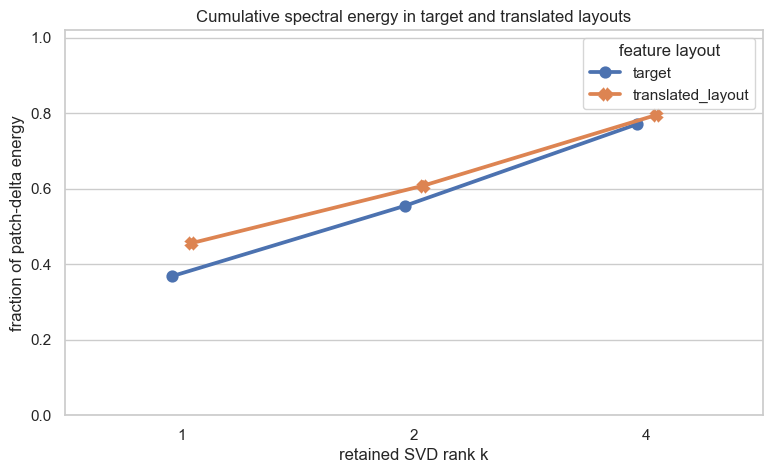

In [2]:
metric_cols = ['rank1_energy_fraction', 'rank2_energy_fraction', 'rank4_energy_fraction']
long = spectrum.melt(
    id_vars=['example_id', 'analysis_group', 'set_kind'],
    value_vars=metric_cols, var_name='rank', value_name='energy_fraction',
)
long['rank_k'] = long['rank'].str.extract(r'rank(\d+)').astype(int)
primary_kinds = ['target', 'translated_layout']
fig, ax = plt.subplots(figsize=(9, 5))
sns.pointplot(
    data=long[long.set_kind.isin(primary_kinds)], x='rank_k', y='energy_fraction',
    hue='set_kind', errorbar=('ci', 95), dodge=0.08, markers=['o', 'X'], ax=ax,
)
ax.set(title='Cumulative spectral energy in target and translated layouts',
       xlabel='retained SVD rank k', ylabel='fraction of patch-delta energy', ylim=(0, 1.02))
ax.legend(title='feature layout')
plt.show()

**Что видно.** Target layout оказался **менее**, а не более низкоранговым, чем translated control: rank-1 объясняет в среднем 0.368 энергии против 0.455, rank-2 — 0.555 против 0.608, rank-4 — 0.771 против 0.795. Парное различие rank-1 равно −0.087; target выше контроля только в 21.2% примеров (`Wilcoxon p≈1.6e−40`). Поэтому target-specific rank-1 enrichment отвергается. Вероятная причина — признаки самого объекта разнообразнее гладких фоновых областей. Высокий первый singular value сам по себе не является механизмом hiding.

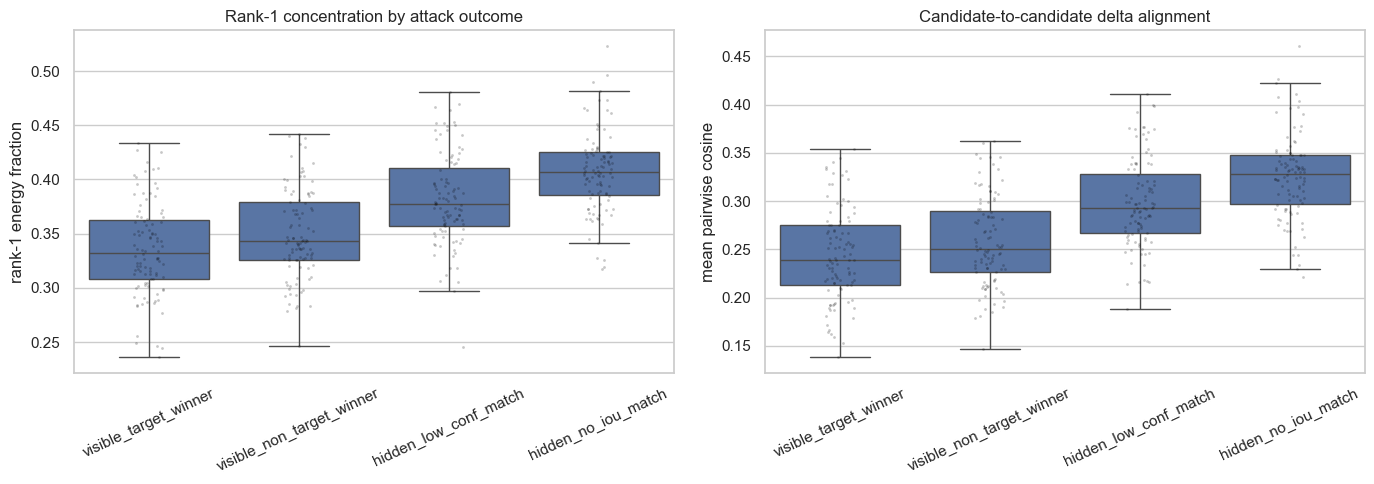

In [3]:
order = ['visible_target_winner', 'visible_non_target_winner',
         'hidden_low_conf_match', 'hidden_no_iou_match']
target_spectrum = spectrum[spectrum.set_kind.eq('target')].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=target_spectrum, x='analysis_group', y='rank1_energy_fraction',
            order=order, showfliers=False, ax=axes[0])
sns.stripplot(data=target_spectrum, x='analysis_group', y='rank1_energy_fraction',
              order=order, color='black', alpha=.22, size=2, ax=axes[0])
axes[0].set(title='Rank-1 concentration by attack outcome', xlabel='', ylabel='rank-1 energy fraction')
axes[0].tick_params(axis='x', rotation=25)
sns.boxplot(data=target_spectrum, x='analysis_group', y='mean_pairwise_cosine',
            order=order, showfliers=False, ax=axes[1])
sns.stripplot(data=target_spectrum, x='analysis_group', y='mean_pairwise_cosine',
              order=order, color='black', alpha=.22, size=2, ax=axes[1])
axes[1].set(title='Candidate-to-candidate delta alignment', xlabel='', ylabel='mean pairwise cosine')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

**Что видно.** Внутри target layout связь с успехом сильная и монотонная. Средняя rank-1 fraction растёт от 0.336 (`visible_target_winner`) и 0.349 (`visible_non_target_winner`) до 0.382 (`hidden_low_conf`) и 0.407 (`hidden_no_iou`). Mean pairwise cosine аналогично растёт примерно с 0.244/0.258 до 0.298/0.326. Объединённое hidden-vs-visible различие значимо (`p≈1.8e−26` для rank-1 и `p≈8.5e−28` для cosine); соответствующие single-metric ROC AUC равны 0.808 и 0.816. Значит, успешная атака действительно синхронизирует изменения кандидатов сильнее, особенно при потере IoU, но эта синхронизация существует на фоне ещё более низкоранговых нетаргетных областей.

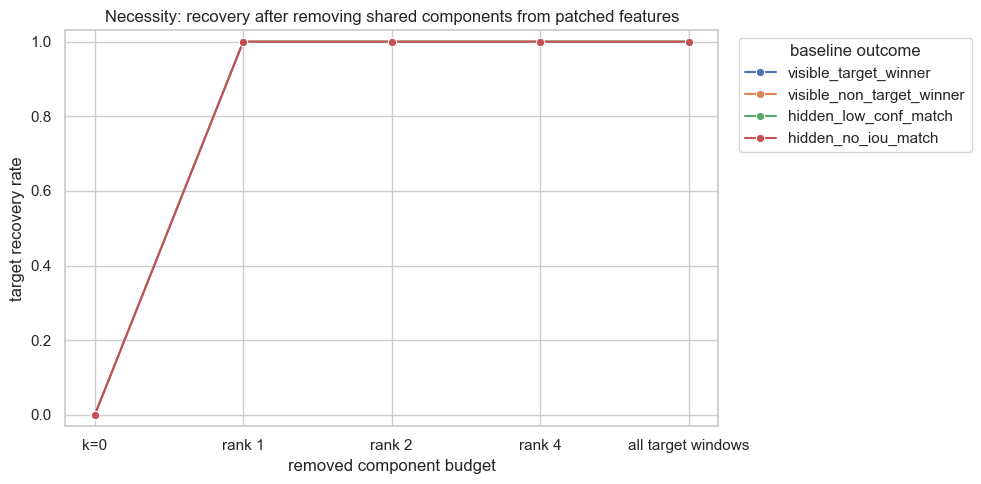

In [4]:
dose_order = ['none', 'rank1_common', 'rank2_common', 'rank4_common', 'full_target_windows']
dose_labels = {'none': 'k=0', 'rank1_common': 'rank 1', 'rank2_common': 'rank 2',
               'rank4_common': 'rank 4', 'full_target_windows': 'all target windows'}
repair = interventions[(interventions.direction == 'repair_patched') &
                       (interventions.analysis_group != 'all') &
                       interventions.condition.isin(dose_order)].copy()
repair['dose'] = pd.Categorical(repair.condition, dose_order, ordered=True)
repair['dose_label'] = repair.condition.map(dose_labels)
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=repair.sort_values('dose'), x='dose_label', y='recovery_rate',
             hue='analysis_group', hue_order=order, marker='o', ax=ax)
ax.set(title='Necessity: recovery after removing shared components from patched features',
       xlabel='removed component budget', ylabel='target recovery rate', ylim=(-.03, 1.03))
ax.legend(title='baseline outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

**Что видно.** Удаление rank-1 компоненты возвращает все 193 targets, остававшиеся hidden при повторном inference: recovery 100% и для low-confidence, и для no-IoU. Средний post-confidence возрастает примерно до 0.595/0.590, IoU — до 0.904/0.882. Последующие rank-2/rank-4 уже не могут улучшить бинарный recovery из-за потолка, но продолжают повышать confidence и IoU. Следовательно, rank-1 содержит достаточную для **восстановления** часть изменения, однако necessity нельзя заключать из repair без controls и обратного transplant.

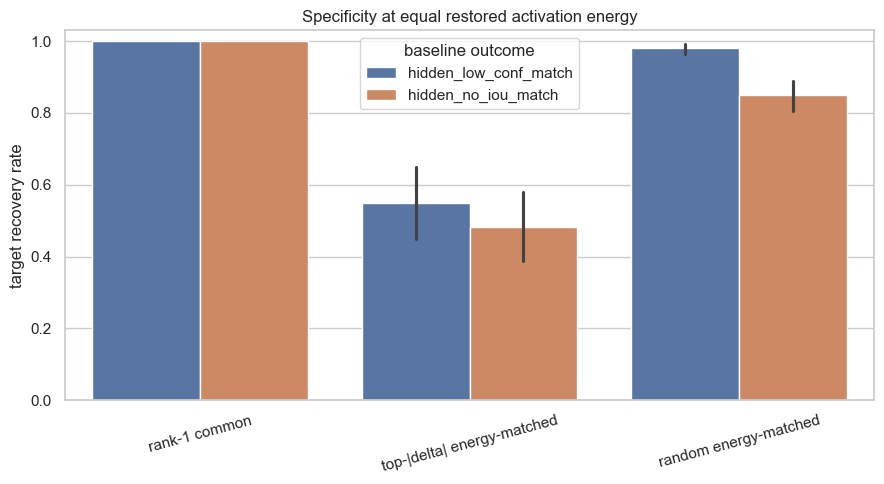

In [5]:
controls = ['rank1_common', 'topabs_energy_rank1',
            'random_energy_rank1_0', 'random_energy_rank1_1', 'random_energy_rank1_2']
control_rows = rows[(rows.direction == 'repair_patched') & rows.condition.isin(controls)].copy()
control_rows['control'] = np.where(
    control_rows.condition.str.startswith('random_'), 'random energy-matched',
    control_rows.condition.map({'rank1_common': 'rank-1 common',
                                'topabs_energy_rank1': 'top-|delta| energy-matched'}),
)
hidden = control_rows[control_rows.baseline_hidden.eq(1)]
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=hidden, x='control', y='target_detected', hue='analysis_group',
            hue_order=order[2:], errorbar=('ci', 95), ax=ax)
ax.set(title='Specificity at equal restored activation energy', xlabel='',
       ylabel='target recovery rate', ylim=(0, 1.03))
ax.tick_params(axis='x', rotation=15)
ax.legend(title='baseline outcome')
plt.tight_layout(); plt.show()

**Что видно.** Rank-1 даёт 100% recovery, но случайная energy-matched реставрация тоже даёт в среднем около 91.7%: 97–99% для low-confidence и 84–86% для no-IoU. Только 9 примеров спасаются rank-1 при провале всех трёх random controls. Top-|delta| восстанавливает лишь 55%/48%, хотя возвращает ту же энергию: концентрация на крупнейших координатах хуже распределённого покрытия окна. Значит, rank-1 удобен как плотный repair-базис, но его преимущество недостаточно специфично, чтобы объявить первую SVD-компоненту самостоятельным механизмом.

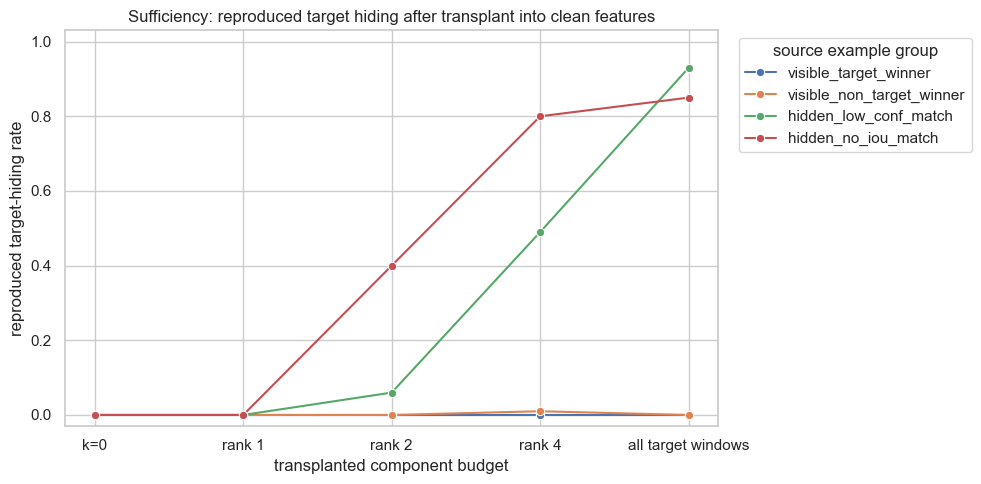

In [6]:
transplant = interventions[(interventions.direction == 'transplant_clean') &
                           (interventions.analysis_group != 'all') &
                           interventions.condition.isin(dose_order)].copy()
transplant['dose'] = pd.Categorical(transplant.condition, dose_order, ordered=True)
transplant['dose_label'] = transplant.condition.map(dose_labels)
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=transplant.sort_values('dose'), x='dose_label', y='reproduced_hiding_rate',
             hue='analysis_group', hue_order=order, marker='o', ax=ax)
ax.set(title='Sufficiency: reproduced target hiding after transplant into clean features',
       xlabel='transplanted component budget', ylabel='reproduced target-hiding rate',
       ylim=(-.03, 1.03))
ax.legend(title='source example group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

**Что видно.** Rank-1 transplant не скрывает target ни в одном из 400 примеров. Rank-2 воспроизводит 6% low-confidence и 40% no-IoU, rank-4 — 49% и 80%. Полный target-window delta воспроизводит 93% и 85% исходно успешных атак, но **0%** в обеих visible-группах. В сумме это 178/200 hidden-source и 0/200 visible-source. Следовательно, локальное изменение Detect inputs почти достаточно и outcome-specific, но оно многомерно: одна общая feature direction не ломает reserve. Более быстрый рост no-IoU согласуется с ранее найденным более сильным и нелинейным режимом атаки.

In [7]:
overall_spec = spectrum_summary[spectrum_summary.analysis_group.eq('all')].set_index('set_kind')
overall_int = interventions[interventions.analysis_group.eq('all')].set_index(['direction', 'condition'])
display(overall_spec[[c for c in overall_spec.columns if c.startswith('mean_')]].round(3))
display(overall_int[[
    'mean_component_energy_fraction', 'recovery_rate', 'reproduced_hiding_rate',
    'mean_post_target_conf', 'mean_post_target_iou',
]].round(3))

,mean_candidates,mean_rank1_energy_fraction,mean_rank2_energy_fraction,mean_rank4_energy_fraction,mean_effective_rank,mean_mean_pairwise_cosine
set_kind,,,,,,
target,10.29,0.368,0.554,0.771,6.588,0.281
translated_layout,10.29,0.455,0.608,0.795,5.799,0.383
matched_random,5.97,0.505,0.710,0.887,4.303,0.320


mean_component_energy_fraction  \
direction        condition                                               
repair_patched   none                                            0.000   
                 rank1_common                                    0.368   
                 rank2_common                                    0.554   
                 rank4_common                                    0.771   
                 topabs_energy_rank1                             0.368   
                 random_energy_rank1_0                           0.368   
                 random_energy_rank1_1                           0.368   
                 random_energy_rank1_2                           0.368   
                 full_target_windows                             1.000   
transplant_clean none                                            0.000   
                 rank1_common                                    0.368   
                 rank2_common                                    0.554   
                 rank4_common                                    0.771   
                 topabs_energy_rank1                             0.368   
                 random_energy_rank1_0                           0.368   
                 random_energy_rank1_1                           0.368   
                 random_energy_rank1_2                           0.368   
                 full_target_windows                             1.000   

                                        recovery_rate  reproduced_hiding_rate  \
direction        condition                                                      
repair_patched   none                           0.000                   0.000   
                 rank1_common                   1.000                   0.000   
                 rank2_common                   1.000                   0.000   
                 rank4_common                   1.000                   0.000   
                 topabs_energy_rank1            0.518                   0.005   
                 random_energy_rank1_0          0.922                   0.000   
                 random_energy_rank1_1          0.922                   0.000   
                 random_energy_rank1_2          0.907                   0.000   
                 full_target_windows            1.000                   0.000   
transplant_clean none                             NaN                   0.000   
                 rank1_common                     NaN                   0.000   
                 rank2_common                     NaN                   0.115   
                 rank4_common                     NaN                   0.325   
                 topabs_energy_rank1              NaN                   0.000   
                 random_energy_rank1_0            NaN                   0.000   
                 random_energy_rank1_1            NaN                   0.000   
                 random_energy_rank1_2            NaN                   0.000   
                 full_target_windows              NaN                   0.445   

                                        mean_post_target_conf  \
direction        condition                                      
repair_patched   none                                   0.336   
                 rank1_common                           0.679   
                 rank2_common                           0.799   
                 rank4_common                           0.878   
                 topabs_energy_rank1                    0.488   
                 random_energy_rank1_0                  0.623   
                 random_energy_rank1_1                  0.623   
                 random_energy_rank1_2                  0.620   
                 full_target_windows                    0.904   
transplant_clean none                                   0.904   
                 rank1_common                           0.786   
                 rank2_common                           0.604   
                 rank4_commo

## Итог эксперимента

Гипотеза единственного общего rank-1 bottleneck **отвергнута**: target layout не имеет spectral enrichment относительно translated control, rank-1 transplant даёт 0% hiding, а random energy-matched repair почти повторяет его restorative effect.

При этом эксперимент дал более сильный локализационный результат. Полный clean→patch delta только в объединении `5×5` окон clean target candidates необходим для repair (100%) и почти достаточен для воспроизведения исходного исхода: 89% среди hidden-source и 0% среди visible-source. Успех связан не с одним направлением, а с более согласованным **многомерным target-local subspace**: первые четыре SVD-компоненты уже воспроизводят 49% low-confidence и 80% no-IoU атак.

Следующий механизм надо искать не через обычный energy-SVD, а через functionally weighted subspace: направления Detect-input delta, совместно уменьшающие logits/geometry всего clean candidate set. Наиболее прямой следующий эксперимент — joint-candidate Jacobian/IG decomposition с rank-k repair/transplant и теми же spatial/energy controls. Он проверит, становится ли причинно важный subspace существенно меньше после учёта чувствительности модели, а не только дисперсии активаций.